In [1]:
# Unzip the uploaded data into Google drive
#!unzip "/content/drive/MyDrive/Dog Vision/dog-breed-identification.zip" -d "drive/MyDrive/Dog Vision/"

# Using Transfer Learning and TensorFlow 2.0 to Classify Different Dog Breeds

Who's that doggy in the window?

Dogs are incredible. But have you ever been sitting at a cafe, seen a dog and not known what breed it is? I have. And then someone says, "it's an English Terrier" and you think, how did they know that?

In this project we're going to be using machine learning to help us identify different breeds of dogs.

To do this, we'll be using data from the Kaggle dog breed identification competition. It consists of a collection of 10,000+ labelled images of 120 different dog breeds.

This kind of problem is called multi-class image classification. It's multi-class because we're trying to classify mutliple different breeds of dog. If we were only trying to classify dogs versus cats, it would be called binary classification (one thing versus another).

Multi-class image classification is an important problem because it's the same kind of technology Tesla uses in their self-driving cars or Airbnb uses in atuomatically adding information to their listings.

Since the most important step in a deep learng problem is getting the data ready (turning it into numbers), that's what we're going to start with.

We're going to go through the following TensorFlow/Deep Learning workflow:

1. Get data ready (download from Kaggle, store, import).

2. Prepare the data (preprocessing, the 3 sets, X & y).

3. Choose and fit/train a model (TensorFlow Hub, tf.keras.applications, TensorBoard, EarlyStopping).

4. Evaluating a model (making predictions, comparing them with the ground truth labels).

5. Improve the model through experimentation (start with 1000 images, make sure it works, increase the number of images).

6. Save, sharing and reloading your model (once you're happy with the results).

For preprocessing our data, we're going to use TensorFlow 2.x. The whole premise here is to get our data into Tensors (arrays of numbers which can be run on GPUs) and then allow a machine learning model to find patterns between them.

For our machine learning model, we're going to be using a pretrained deep learning model from TensorFlow Hub.

The process of using a pretrained model and adapting it to your own problem is called **transfer learning**. We do this because rather than train our own model from scratch (could be timely and expensive), we leverage the patterns of another model which has been trained to classify images.



## Getting our workspace ready

In [2]:
# Import TensorFlow
import tensorflow as tf
import tensorflow_hub as hub
import keras

print("TF version:", tf.__version__)
print("Hub version:", hub.__version__)
print("Keras:", keras.__version__)

# Check for GPU
print("GPU", "available (YESS!!!!)" if tf.config.list_physical_devices("GPU") else "not available :(")

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TF version: 2.21.0
Hub version: 0.16.1
Keras: 3.13.2
GPU available (YESS!!!!)


## Getting our data ready (turning into Tenso)

In [3]:
# checkout the labels of our data
import pandas as pd

labels_csv = pd.read_csv("/content/drive/MyDrive/Dog Vision/labels.csv")
labels_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


In [4]:
labels_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10222 entries, 0 to 10221
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10222 non-null  object
 1   breed   10222 non-null  object
dtypes: object(2)
memory usage: 159.8+ KB


In [5]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


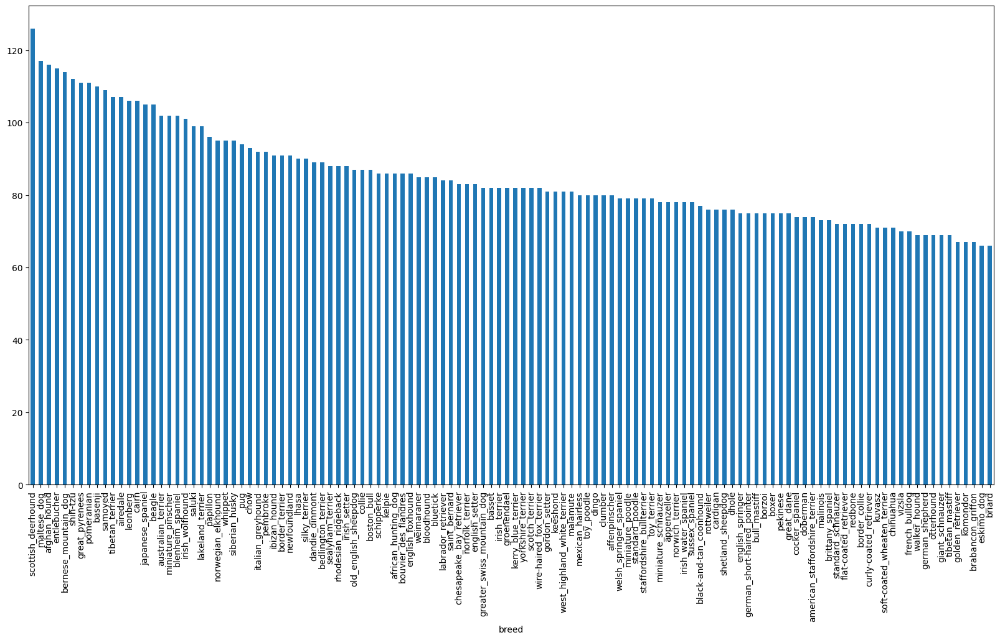

In [6]:
# How many images are there of eech breed?
labels_csv["breed"].value_counts().plot.bar(figsize=(20, 10));

In [7]:
labels_csv["breed"].value_counts().median()

82.0

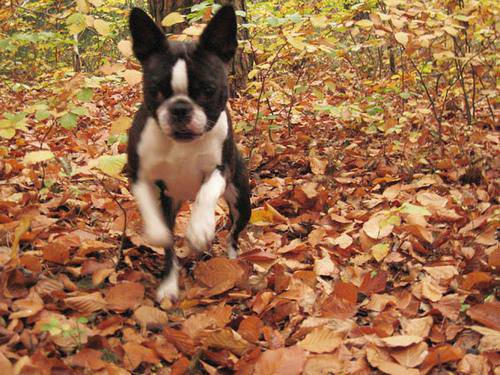

In [8]:
# Let's view an image
from IPython.display import Image
Image("/content/drive/MyDrive/Dog Vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

### Getting images and their labels

Let's get a list of all our image file pathnames

In [9]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [10]:
# Create pathname from image ID's
filenames = ["drive/MyDrive/Dog Vision/train/" + fname + ".jpg" for fname in labels_csv["id"]]

# check the first 10
filenames

['drive/MyDrive/Dog Vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'drive/MyDrive/Dog Vision/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'drive/MyDrive/Dog Vision/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'drive/MyDrive/Dog Vision/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'drive/MyDrive/Dog Vision/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'drive/MyDrive/Dog Vision/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'drive/MyDrive/Dog Vision/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'drive/MyDrive/Dog Vision/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'drive/MyDrive/Dog Vision/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'drive/MyDrive/Dog Vision/train/0042188c895a2f14ef64a918ed9c7b64.jpg',
 'drive/MyDrive/Dog Vision/train/004396df1acd0f1247b740ca2b14616e.jpg',
 'drive/MyDrive/Dog Vision/train/0067dc3eab0b3c3ef0439477624d85d6.jpg',
 'drive/MyDrive/Dog Vision/train/00693b8bc2470375cc744a6391d397ec.jpg',
 'drive/MyDrive/Dog Vision/train/006cc3ddb9dc1bd827479569fcdc52d

In [11]:
# check whether number of filenames matches number of actual image files
import os

if len(os.listdir("drive/MyDrive/Dog Vision/train")) == len(filenames):
  print("Filenames match actual amount of files!!! Proceed.")
else:
  print("Filenames do not match actual amount of fles, check the target directory.")

Filenames match actual amount of files!!! Proceed.


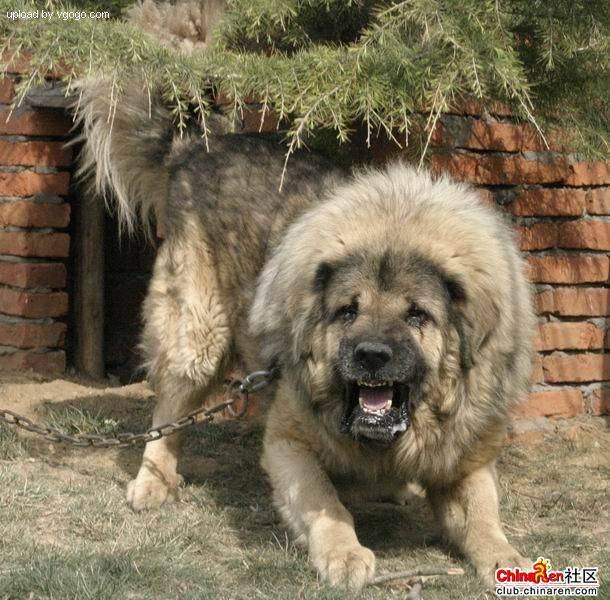

In [12]:
# one more check
Image(filenames[9000])

In [13]:
labels_csv["breed"][9000]

'tibetan_mastiff'

Since we've now got our training image filepaths in a list, let's prepare our labels.

In [14]:
import numpy as np

labels = labels_csv["breed"].to_numpy()
# labels = np.array(labels) # does same thing as above
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [15]:
len(labels)

10222

In [16]:
# see if number of labels matches the number if filenames
if len(labels) == len(filenames):
  print("Number of labels matches number of filenames!")
else:
  print("Number of labels does not match number of filenames, check data directories.")

Number of labels matches number of filenames!


In [17]:
# find the unique label values
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [18]:
len(unique_breeds)

120

In [19]:
# Example: Turn one label into an array of booleans
print(labels[0])
labels[0] == unique_breeds # use comparison operator to create boolean array

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [20]:
from pandas.core.arrays import boolean
# Turn every label into a boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [21]:
len(boolean_labels)

10222

In [22]:
# Example: Turning boolean array nto integers
print(labels[0]) # original label
print(np.where(unique_breeds == labels[0])) # index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # there will be a 1 where the sample label occurs

boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


##### Creating our own validation set
Since the dataset from kaggle doesn't come with a validaton set, we're going to create our own.

In [23]:
# setup x & y variables
x = filenames
y = boolean_labels

In [24]:
len(filenames)

10222

we're going to start off experimenting ~1000 images and increase as needed

In [25]:
# set number of images to use for experimenting
NUM_IMAGES = 10000 #@param {type:"slider", min:1000, max:10000, step:1000}

In [26]:
# Let'split or data into train and validaton sets
from sklearn.model_selection import train_test_split

# split them into training and validation of total size NUM_IMAGES
x_train, x_val, y_train, y_val = train_test_split(x[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size=0.2,
                                                  random_state=42,
                                                  stratify=y[:NUM_IMAGES])

In [27]:
len(x_train), len(y_train), len(x_val), len(y_val)

(8000, 8000, 2000, 2000)

In [28]:
# let's have a look at the training data
x_train[:5], y_train[:2]

(['drive/MyDrive/Dog Vision/train/a8040246b5632253425a04dbb3cce104.jpg',
  'drive/MyDrive/Dog Vision/train/146c249bf2d60bf30c309341020bf2ee.jpg',
  'drive/MyDrive/Dog Vision/train/bd3086afcdf8d1571c615fe7c7472e11.jpg',
  'drive/MyDrive/Dog Vision/train/c6ae68d5e1e8d543b2cabc4c76097cbf.jpg',
  'drive/MyDrive/Dog Vision/train/cdb32ac86d0475b5d32667582acaf267.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, 

## Preprocessing Images (Turn images into Tensors)

To preprocess our images into tensors we're going to write a function which does a few things
1. Take an images filepath as input

2. use tensorflow to read the file and save it to a variable, `image`

3. Turn our `image` (a jpg) into Tensors

4. Resize the `image` to be a shape of (224, 224)

5. Returrn the modified `image`

Before we do, let's see what importing an image looks like

In [29]:
# convert image to Numpy array
from matplotlib.pyplot import imread

image = imread(filenames[42])
image.shape

(257, 350, 3)

In [30]:
image.max()

np.uint8(255)

In [31]:
image.min()

np.uint8(0)

In [32]:
image[:2]

array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)

In [33]:
# turn image into a tensor
tf.constant(image[:2])

<tf.Tensor: shape=(2, 350, 3), dtype=uint8, numpy=
array([[[ 89, 137,  89],
        [ 76, 124,  76],
        [ 63, 111,  61],
        ...,
        [ 77, 133,  86],
        [ 76, 134,  86],
        [ 76, 134,  86]],

       [[ 72, 119,  75],
        [ 67, 114,  68],
        [ 63, 110,  64],
        ...,
        [ 75, 131,  84],
        [ 74, 132,  84],
        [ 74, 132,  84]]], dtype=uint8)>

Now we;ve seen what an image looks like  as a Tensor, let's make a function to preprocess them.

1. Take an images filepath as input

2. use tensorflow to read the file and save it to a variable, `image`

3. Turn our `image` (a jpg) into Tensors

4. Normalize our image (convert colour channel values from 0-255 to 0-1)

5. Resize the `image` to be a shape of (224, 224)

6. Returrn the modified `image`

In [34]:
# Define image size
IMG_SIZE = 224

# create a function for preprocessing images
def process_image(image_path, img_size=IMG_SIZE):
  """
  Takes an image file path and turns the image
  into a Tensor
  """
  # Read in an image file
  image = tf.io.read_file(image_path)
  # Turn the jpeg into numerical Tensor with 3 colour channnels (Red, Green, Blue)
  image = tf.image.decode_jpeg(image, channels=3)
  #convert the colour channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
  # Resize the image to our desired value (224, 224)
  image = tf.image.resize(image, size=[IMG_SIZE, IMG_SIZE])

  return image

## Turning our data into batches

Why turn our data into batches?

let's say you're trying to process 10000+ images in one go... they all might not fit into memory.

So that's why we do about 32 (this is the batch size) images at a time (you can manually adjust the batch size if need be).

In order to use Tensorflow effectively, we need our data in the form of Tensor tuples which look like this: `(image, label)`

In [35]:
# create a simple function to return a tuple (image, label)
def get_image_label(image_path, label):
  """
  Takes an image file path name and the assosciated label,
  processes the image and returns a tuple of (image, label).
  """
  image = process_image(image_path)
  return image, label

In [36]:
# Demo of the above
(process_image(x[42]), tf.constant(y[42]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.3264178 , 0.5222886 , 0.3232816 ],
         [0.2537167 , 0.44366494, 0.24117757],
         [0.25699762, 0.4467087 , 0.23893751],
         ...,
         [0.29325107, 0.5189916 , 0.3215547 ],
         [0.29721776, 0.52466875, 0.33030328],
         [0.2948505 , 0.5223015 , 0.33406618]],
 
        [[0.25903144, 0.4537807 , 0.27294815],
         [0.24375686, 0.4407019 , 0.2554778 ],
         [0.2838985 , 0.47213382, 0.28298813],
         ...,
         [0.2785345 , 0.5027992 , 0.31004712],
         [0.28428748, 0.5108719 , 0.32523635],
         [0.28821915, 0.5148036 , 0.32916805]],
 
        [[0.20941195, 0.40692952, 0.25792548],
         [0.24045378, 0.43900946, 0.2868911 ],
         [0.29001117, 0.47937486, 0.32247734],
         ...,
         [0.26074055, 0.48414773, 0.30125174],
         [0.27101526, 0.49454468, 0.32096273],
         [0.27939945, 0.5029289 , 0.32934693]],
 
        ...,
 
        [[0.00634795, 0.03442048

Now we've got a way to turn our data into tuples of Tensors in the form: `(image, label)`, let's make a function to turm all of our data (x & y) into batches

In [37]:
# Define the batch size, 32 is a good start
BATCH_SZE = 32

# Create a function to turn data into batches
def create_data_batches(x, y=None, batch_size=BATCH_SZE, valid_data=False, test_data=False):
  """
  Creates batches of data out of image (x) and label (y) pairs.
  Shuffles the data if it's training data but doesn't shuffle if it's validation data.
  Also accepts test data as input (no labels).
  """
  # if the data is a test dataset, we probably don't have labels
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(x))) # only filepaths (no labels)
    data_batch = data.map(process_image).batch(BATCH_SZE)
    return data_batch

 # If the data is a valid dataset, we don't need to shuffle it
  elif valid_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(x), # filepaths
                                             tf.constant(y))) # labels
    data_batch = data.map(get_image_label).batch(BATCH_SZE)
    return data_batch

  else:
    print("Creating training data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(x),
                                             tf.constant(y)))
    # shuffling pathnames and labels before mapping image processor function is faster than shuffling images
    data = data.shuffle(buffer_size=len(x))

    # create (image, label) tuples (this also turns the image path into a preprocessed image)
    data = data.map(get_image_label)

    # Turn the trainng data into batches
    data_batch = data.batch(BATCH_SZE)

  return data_batch

In [38]:
# Create training and validation data batches
train_data = create_data_batches(x_train, y_train)
val_data = create_data_batches(x_val, y_val, valid_data=True)

Creating training data batches...
Creating validation data batches...


In [39]:
# check out the differemt attributes of our data batches
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

# Visualizing Data Batches

Our data is now in batches, however, these can be a little hard to understand, let's visualize them

In [40]:
import matplotlib.pyplot as plt

# create a function for viewing images in a data batch
def show_25_images(images, labels):
  """
  Displays a plot of 25 images and their labels from a data batch.
  """
  # Setup the figure
  plt.figure(figsize=(10, 10))
  # Loop through 25 (for displaying 25 images)
  for i in range(25):
    # create subplots(5 rows, 5 columns)
    ax = plt.subplot(5, 5, i+1)
    # Display an image
    plt.imshow(images[i])
    # Add the image label as the title
    plt.title(unique_breeds[labels[i].argmax()])
    # Turn the grid lines off
    plt.axis("off")

In [41]:
train_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [42]:
train_images, train_labels = next(train_data.as_numpy_iterator())

In [43]:
len(train_images), len(train_labels)

(32, 32)

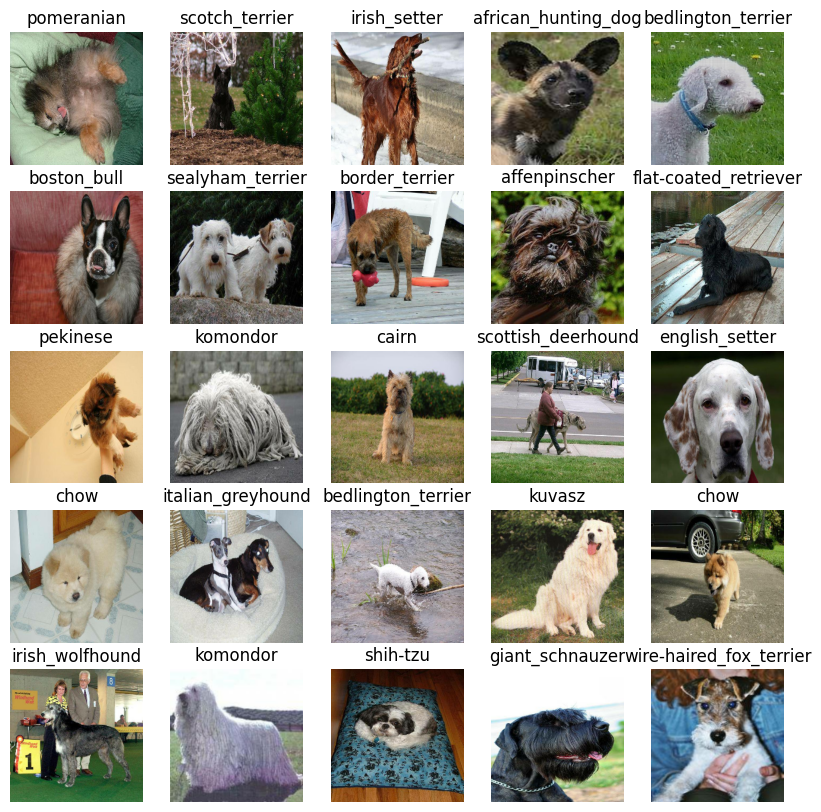

In [44]:
# Now let's visualize the data in a training batch
show_25_images(train_images, train_labels)

In [45]:
# # Now let's visualize our validation set
# val_images, val_labels = next(val_data.as_numpy_iterator())
# show_25_images(val_images, val_labels)

### Building a Model

Before we build a model, there are a few things we need to define:
- The input shape (our images shape, in the form of Tensors) to our model.

- The output shape(image labels, in the form of Tensors) of our model.

- The URL of the model we want to use from TensorFlow Hub - https://www.tensorflow.org/tutorials/images/transfer_learning_with_hub#an_imagenet_classifier

In [46]:
IMG_SIZE

224

In [47]:
# Setup input shape to the model
INPUT_SHAPE = [IMG_SIZE, IMG_SIZE, 3] # batch, height, width, colour channels

# setup output shape of our model
OUTPUT_SHAPE = len(unique_breeds)

# Setup model URL from Tensorflow Hub
#MODEL_URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

Now we've got our inputs, outputs and model ready to go. Let's put them together into a keras deep learning model!

Knowing this, let's create a function which:
- Takes the input shape, output shape and the model we've chosen as parameters.
- Define the layers in a keras model in sequential fashion(do this first, then ths, then that).
- Compiles the model(says it should be evaluated and improved).
- Builds the model(tells the model the input shape it'll be getting).
- Returns the model

In [48]:
# # # Create a function which builds a keras model
# def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
#   print("Building model with:", MODEL_URL)

#   # setup the model layers
#   model = tf.keras.Sequential([
#       hub.KerasLayer(model_url), # Layer 1 (input layer)
#       tf.keras.layers.Dense(units=output_shape,
#                             activation="softmax") # Layer 2 (output layer)
#   ])

#   # compile the model
#   model.compile(
#       loss=tf.keras.losses.CategoricalCrossentropy(),
#       optimizer=tf.keras.optimizers.Adam(),
#       metrics=["accuracy"]
#   )

#   # Build the model
#   model.build(input_shape)

#   return model

In [49]:
# def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE):
#     print("Building CNN from scratch")

#     model = tf.keras.Sequential([
#         tf.keras.layers.Input(shape=input_shape),

#         # Data augmentation
#         tf.keras.layers.RandomFlip("horizontal"),
#         tf.keras.layers.RandomRotation(0.1),
#         tf.keras.layers.RandomZoom(0.1),

#         # CNN layer 1
#         tf.keras.layers.Conv2D(
#             filters=32,
#             kernel_size=3,
#             activation="relu"
#         ),
#         tf.keras.layers.MaxPooling2D(pool_size=2),

#         # CNN layer 2
#         tf.keras.layers.Conv2D(
#             filters=64,
#             kernel_size=3,
#             activation="relu"
#         ),
#         tf.keras.layers.MaxPooling2D(pool_size=2),

#         # CNN layer 3
#         tf.keras.layers.Conv2D(
#             filters=128,
#             kernel_size=3,
#             activation="relu"
#         ),
#         tf.keras.layers.MaxPooling2D(pool_size=2),

#         # Summarize feature maps
#         tf.keras.layers.GlobalAveragePooling2D(),

#         # Small fully connected layer
#         tf.keras.layers.Dense(
#             units=128,
#             activation="relu"
#         ),

#         # Output
#         tf.keras.layers.Dense(
#             units=output_shape,
#             activation="softmax"
#         )
#     ])

#     model.compile(
#         loss=tf.keras.losses.CategoricalCrossentropy(),
#         optimizer=tf.keras.optimizers.Adam(),
#         metrics=["accuracy"]
#     )

#     return model

In [50]:
# Create a function which builds a Keras model
def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE):

    # Load pretrained MobileNetV2
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze the pretrained layers
    base_model.trainable = False

    # Build the model
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(
            units=output_shape,
            activation="softmax"
        )
    ])

    # Compile the model
    model.compile(
        loss=tf.keras.losses.CategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"]
    )

    return model

In [51]:
# Build the model
model = create_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Creating Callbacks

Callbacks are helper functions a model can use during training to do such things as save its progress, check its progress or stop training early if a model stops improving.

We'll create two callbacks, one for TensoBoard which helps track our models progress and another for early stopping which prevents our model from training for too long.

### TensorBoard Callback
To setup a TensorBoard callback, we need to do 3 things:
1. Load the TensorBoard notebook extension.
2. Create a TensorBoard callback which is able to save logs to a directory and pass it to our model's fit() function.
3. Visualize our models training logs with the %Tensorboard magic function (we'll do this after model training)

In [52]:
# Load TensorBoard notebook extension
%load_ext tensorboard

In [53]:
import datetime

# create a function to build a Tensorboard callback
def create_tensorboard_callback():
  # create a log directory for storing TensorBoard callback
  logdir = os.path.join("drive/MyDrive/Dog Vision/logs",
                        datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  return tf.keras.callbacks.TensorBoard(logdir)

### Early Stopping Callback

Early Stopping helps stop our model from overfitting by stopping training if a certain evaluation metric stops improving

In [54]:
# Create early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy",
                                                  patience=3)

## Training a model (on subset of data)

Our first model is only going to train on 1000 images, to make sure everything is working

In [55]:
NUM_EPOCHS = 100 #@param {type:"slider", min:10, max:100, step:10}

Let's create a function which trains a model.
- Create a model using `create_model()`
- Setup a TensorBoard callback using `create_tensorboard _callback()`
- Call the `fit()` function on our model passing it the training data, validation data, number of epochs to trainfor (`NUM_EPOCHS`) and the callbacks we'd like to use
- Return the model

In [56]:
# Build a function to train and return a trained model
def train_model():
  """
  Trains a given model and returns the trained version.
  """
  # create a model
  model = create_model()

  # create new TensorBoard session everytime we train a model
  tensorboard = create_tensorboard_callback()

  # Fit the model to the data passing it the callbacks we created
  model.fit(x=train_data,
            epochs=NUM_EPOCHS,
            validation_data=val_data,
            validation_freq=1,
            callbacks=[tensorboard, early_stopping])
  # Return the fitted model
  return model

In [57]:
# Fit the model to the data
model = train_model()

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 203s 727ms/step - accuracy: 0.5853 - loss: 1.7367 - val_accuracy: 0.7015 - val_loss: 0.9898
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - accuracy: 0.8374 - loss: 0.5810 - val_accuracy: 0.7275 - val_loss: 0.8788
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 117ms/step - accuracy: 0.9100 - loss: 0.3632 - val_accuracy: 0.7385 - val_loss: 0.8350
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.9505 - loss: 0.2445 - val_accuracy: 0.7350 - val_loss: 0.8094
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 117ms/step - accuracy: 0.9731 - loss: 0.1717 - val_accuracy: 0.7460 - val_loss: 0.8078
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 33s 132ms/step - accuracy: 0.9858 - loss: 0.1272 - val_accuracy: 0.7435 - val_loss: 0.8141
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 125ms/step - accuracy: 0.9920 - loss: 0.0962 - val_accuracy: 0.7490 - val_loss: 0.8171
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - accuracy: 0.9959 

**Question**: It looks like our model is overfittting because it's performing far better on the training dataset than the validation dataset, what are some ways to prevent model overfitting in deep learning neural networks?

**Note**: Overfitting to begin with is a good thing! it means our model is learning!!!

### Checking the Tensorboard logs

The Tensorboard magic function (`%tensorboard`) will access the logs directory we created earlier and visualize its contents

In [58]:
%tensorboard --logdir /content/drive/MyDrive/Dog\ Vision/logs

<IPython.core.display.Javascript object>

## Making and Evaluating predictions using a trained model

In [59]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [60]:
# Make predictions on the validation data (not used to train on)
predictions = model.predict(val_data, verbose=1)
predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step


array([[5.4674442e-06, 1.4370632e-05, 1.1757912e-06, ..., 2.1903143e-06,
        4.0847095e-07, 1.2584922e-08],
       [4.1034700e-06, 1.4138338e-06, 4.7041494e-06, ..., 1.0248691e-06,
        1.2554067e-05, 1.1248662e-07],
       [5.7242588e-08, 9.0617497e-05, 2.6341385e-07, ..., 6.1545550e-04,
        1.5114313e-05, 2.8035501e-07],
       ...,
       [7.8262815e-08, 6.2701287e-07, 6.7246657e-07, ..., 5.4134682e-07,
        3.2886448e-06, 1.4202365e-08],
       [2.4784747e-08, 1.0573898e-06, 2.5659235e-09, ..., 7.5695181e-07,
        9.9780446e-01, 2.9072203e-07],
       [1.8530245e-10, 1.4350706e-09, 6.1688459e-09, ..., 1.1422951e-06,
        2.4270157e-08, 4.5927713e-08]], dtype=float32)

In [61]:
predictions.shape

(2000, 120)

In [62]:
len(y_val)

2000

In [63]:
predictions[0]

array([5.46744423e-06, 1.43706320e-05, 1.17579123e-06, 4.65323495e-07,
       6.45226025e-11, 5.43444956e-10, 1.01508692e-06, 2.21275400e-06,
       8.03024477e-07, 1.21793434e-07, 8.39427361e-10, 3.56361681e-07,
       3.05712122e-09, 1.50395749e-06, 1.12811986e-05, 1.10317773e-08,
       1.11754064e-08, 2.09635764e-05, 1.08335307e-02, 2.98930103e-09,
       1.91075196e-06, 1.81469170e-06, 5.56856321e-08, 1.02477105e-04,
       1.19379149e-06, 1.42877026e-08, 5.85553425e-06, 1.11105946e-04,
       6.38245110e-05, 1.03693914e-07, 4.47926709e-07, 8.49767190e-08,
       2.00863823e-08, 2.64130038e-04, 2.43130565e-08, 1.85449369e-06,
       7.21017204e-05, 3.36439007e-05, 1.09346018e-07, 1.65051131e-06,
       5.21541551e-06, 2.21685870e-09, 7.56302931e-09, 1.00716750e-06,
       7.43670569e-07, 6.80165826e-08, 7.43359735e-04, 1.49325121e-08,
       6.24581560e-08, 2.43782793e-04, 5.49973379e-07, 2.10949622e-08,
       4.68902144e-08, 1.64903142e-07, 1.53039582e-04, 6.31571038e-06,
      

In [64]:
np.sum(predictions[0])

np.float32(1.0)

In [65]:
# First prediction
index = 42
print(predictions[index])
print(f"Max value (propability of prediction): {np.max(predictions[index])}")
print(f"Sum: {np.sum(predictions[index])}")
print(f"Max index: {np.argmax(predictions[index])}")
print(f"Predicted label: {unique_breeds[np.argmax(predictions[index])]}")

[4.67039257e-01 4.88662772e-05 1.69608502e-05 9.23299837e-08
 3.40687034e-09 7.63620012e-09 2.01582257e-03 1.50054448e-05
 6.69397139e-07 3.75407527e-09 4.16921964e-09 1.26245573e-06
 8.30033741e-07 1.52772373e-05 9.25047559e-08 1.53261599e-08
 4.38522875e-06 2.10947533e-07 8.82392499e-07 3.08060265e-07
 8.78390223e-02 4.09667700e-06 2.22883568e-06 3.80673170e-01
 1.79773867e-08 1.07201276e-06 4.59450204e-03 1.33041058e-05
 6.36853699e-08 2.20799109e-07 2.04849854e-07 5.84149291e-07
 1.12134359e-04 6.20351275e-05 1.06100330e-07 2.74418009e-04
 1.80309243e-08 6.44835296e-08 2.47630197e-07 8.80195046e-08
 1.14379118e-05 4.04572269e-08 9.77250465e-07 8.32390015e-08
 1.57734830e-05 1.48830050e-05 2.55620375e-06 1.83336809e-07
 3.64065054e-05 6.68989344e-07 3.11048716e-05 3.64412017e-07
 1.63746865e-08 8.33656344e-08 7.41566619e-05 9.93761873e-08
 8.03653563e-07 8.61598892e-06 2.66868642e-06 3.38410473e-06
 1.17566524e-05 1.30695707e-05 1.62103299e-06 2.00357814e-10
 1.13368667e-04 6.672200

In [66]:
unique_breeds[31]

'clumber'

Having the above functionality is great but we want to be able to do it a scale.

And it would be even better if we could see the image prediction is being made on!

**Note**: Prediction Probabilities are also known as `confidence levels`

In [67]:
# Turn prediction probablities into their respective label ( easier to understand)
def get_pred_label(prediction_probablilities):
  """
  Turn an array of prediction probabilities into a label.
  """
  return unique_breeds[np.argmax(prediction_probablilities)]

# Get a predicted label based on an array of prediction probabilities
pred_label = get_pred_label(predictions[78])
pred_label

'irish_wolfhound'

Now since our validation data is still in a natch dataset, we'll have to unbatchify it to make predictions on the validation images and then compare those predictions to the validation labels(truth labels)

In [68]:
val_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [69]:
# create a function to unbstch a batch dataset
def unbatchify(data):
  """
  Takes a batched dataset of (image, label) Tensors and returns
  separate arrays of images and labels
  """
  images = []
  labels = []

  # loop through unbatched data
  for image, label in data.unbatch().as_numpy_iterator():
    images.append(image)
    labels.append(unique_breeds[np.argmax(label)])
  return images, labels

# unbatch the validation data
val_images, val_labels = unbatchify(val_data)
val_images[0], val_labels[0]

(array([[[0.20550597, 0.23973216, 0.3739671 ],
         [0.1704345 , 0.20100667, 0.35977164],
         [0.16549426, 0.1814776 , 0.36399686],
         ...,
         [0.9725491 , 0.9333334 , 0.82745105],
         [0.9725491 , 0.9333334 , 0.82745105],
         [0.9725491 , 0.9333334 , 0.82745105]],
 
        [[0.15858337, 0.20431659, 0.3316138 ],
         [0.1261675 , 0.16631982, 0.3184327 ],
         [0.11765418, 0.15075281, 0.3277311 ],
         ...,
         [0.9725491 , 0.9333334 , 0.82745105],
         [0.9725491 , 0.9333334 , 0.82745105],
         [0.9725491 , 0.9333334 , 0.82745105]],
 
        [[0.13789392, 0.20481443, 0.3154937 ],
         [0.10765057, 0.17014346, 0.3095676 ],
         [0.09784664, 0.15558144, 0.3210932 ],
         ...,
         [0.9741685 , 0.9349528 , 0.82907045],
         [0.9741685 , 0.9349528 , 0.82907045],
         [0.9741685 , 0.9349528 , 0.82907045]],
 
        ...,
 
        [[0.40861434, 0.24783   , 0.16939862],
         [0.39634445, 0.22526601, 0.15075

Now we've got ways to get:
- Predictions labels.
- Validation labels (truth labels).
- Validation images

let's make some function to make these all a bit more visualize

We'll create a function which:
- Takes an array of prediction probabilities an array of truth labels and an array of images and an integers.
- Convert the prediction probabilities to a predicted label.
- Plot the predicted label, its predicted probability, the truth label and the target image on a single plot.

In [70]:
def plot_pred(prediction_probabilities, labels, images, n=1):
  """
  View the prediction, ground truth and images for samples n
  """
  pred_prob, true_label, image = prediction_probabilities[n], labels[n], images[n]

  # Get the pred label
  pred_label = get_pred_label(pred_prob)

  # Plot image & remove ticks
  plt.imshow(image)
  plt.xticks([])
  plt.yticks([])

  # Change the colour of the title depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # change plot title to be predicted, probability of prediction and truth label
  plt.title("{} {:2.0f}% {}".format(pred_label,
                                    np.max(pred_prob)*100,
                                    true_label),
                                    color=color)

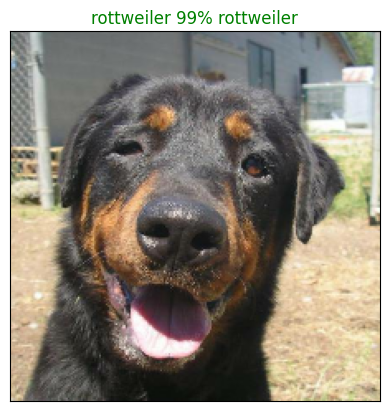

In [71]:
plot_pred(prediction_probabilities=predictions,
          labels=val_labels,
          images=val_images,
          n=100
          )

Now we've got one function to visualize our models top prediction, let's make another to view our models top 10 predictions.

This functon will:
- Take an input of prediction probabilities array and a ground truth array and an integer.
- Find the prediction using `get_pred_labels()
- Find the top 10:
  1. Prediction probabilities indexes
  2. Prediction probabilities values
  3. Prediction labels
- Plot the top 10 prediction probability values and labels, coloring the true  label green

In [72]:
def plot_pred_conf(prediction_probabilities, labels, n=1):
  """
  Plots the top 10 highest prediction confidences along with
  the truth label for sample n.
  """
  pred_prob, true_label = prediction_probabilities[n], labels[n]

  # Get the predicted label
  pred_label = get_pred_label(pred_prob)

  # Find the top 10 prediction confidence indexes
  top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
  # Find the top 10 prediction confidence values
  top_10_pred_values = pred_prob[top_10_pred_indexes]
  # Find the top 10 prediction labels
  top_10_pred_labels = unique_breeds[top_10_pred_indexes]

  # Setup plot
  top_plot = plt.bar(np.arange(len(top_10_pred_labels)),
                     top_10_pred_values,
                     color="grey")
  plt.xticks(np.arange(len(top_10_pred_labels)),
             labels=top_10_pred_labels,
             rotation="vertical")

  # Change color of true label
  if np.isin(true_label, top_10_pred_labels):
    top_plot[np.argmax(top_10_pred_labels == true_label)].set_color("green")
  else:
    pass

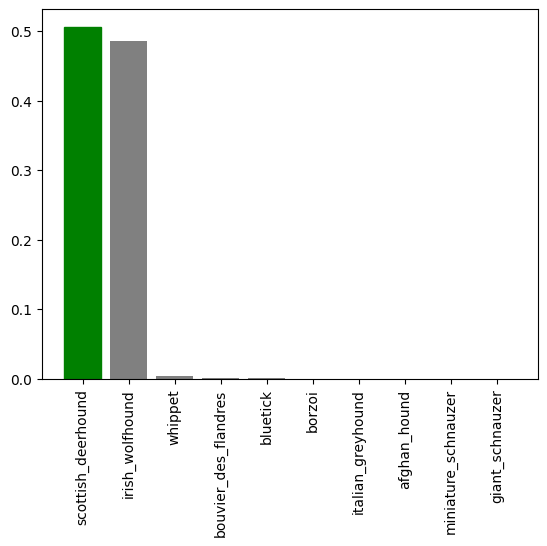

In [73]:
plot_pred_conf(prediction_probabilities=predictions,
               labels=val_labels,
               n=9)

Wonderful! Now we've got some functions to help us visualize our predictions and evaluate our model, let's check out a few.

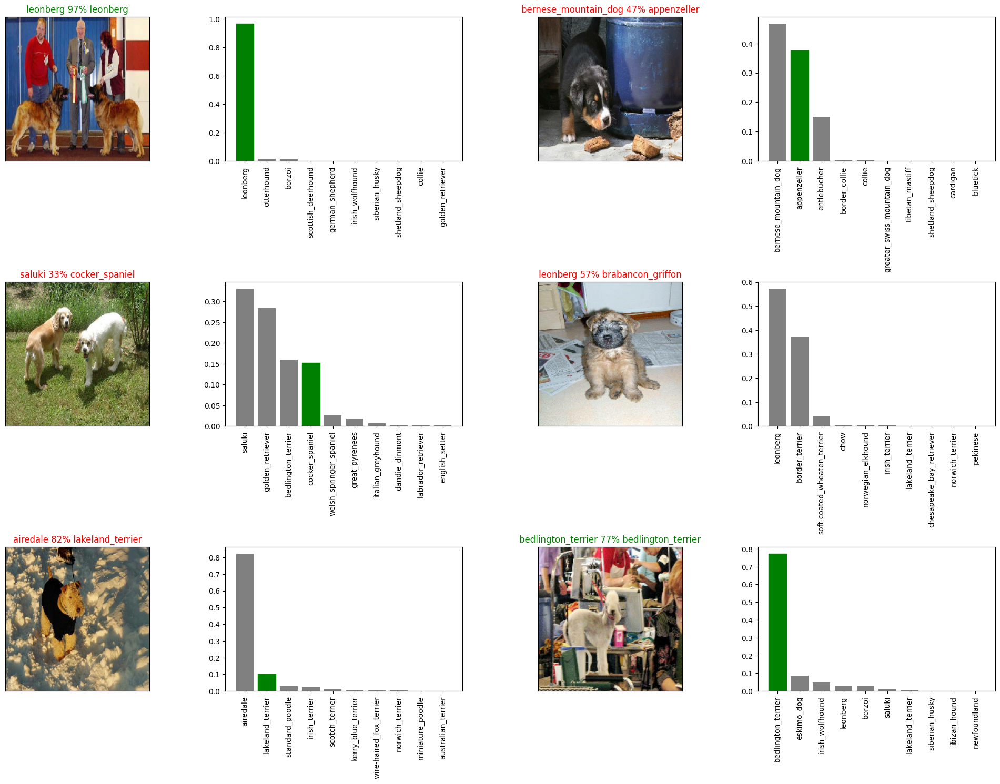

In [74]:
# Let's check a few predictions and their different values
i_multiplier = 0
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(5*2*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_pred(prediction_probabilities=predictions,
            labels=val_labels,
            images=val_images,
            n=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=predictions,
                labels=val_labels,
                n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()

### Plotting the confusion matrix

In [75]:
# confusion matrix
from sklearn.metrics import confusion_matrix


# Convert model probabilities into class numbers
predicted_classes = predictions.argmax(axis=1)

# Convert validation labels into a NumPy array,
# then convert one-hot labels into class numbers
y_val_classes = np.array(y_val).argmax(axis=1)

# Create confusion matrix
cm = confusion_matrix(y_val_classes, predicted_classes)

cm

array([[10,  0,  0, ...,  0,  0,  0],
       [ 0, 22,  0, ...,  0,  0,  0],
       [ 0,  0, 16, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., 13,  0,  0],
       [ 0,  0,  0, ...,  0, 11,  0],
       [ 0,  0,  0, ...,  0,  0, 10]])

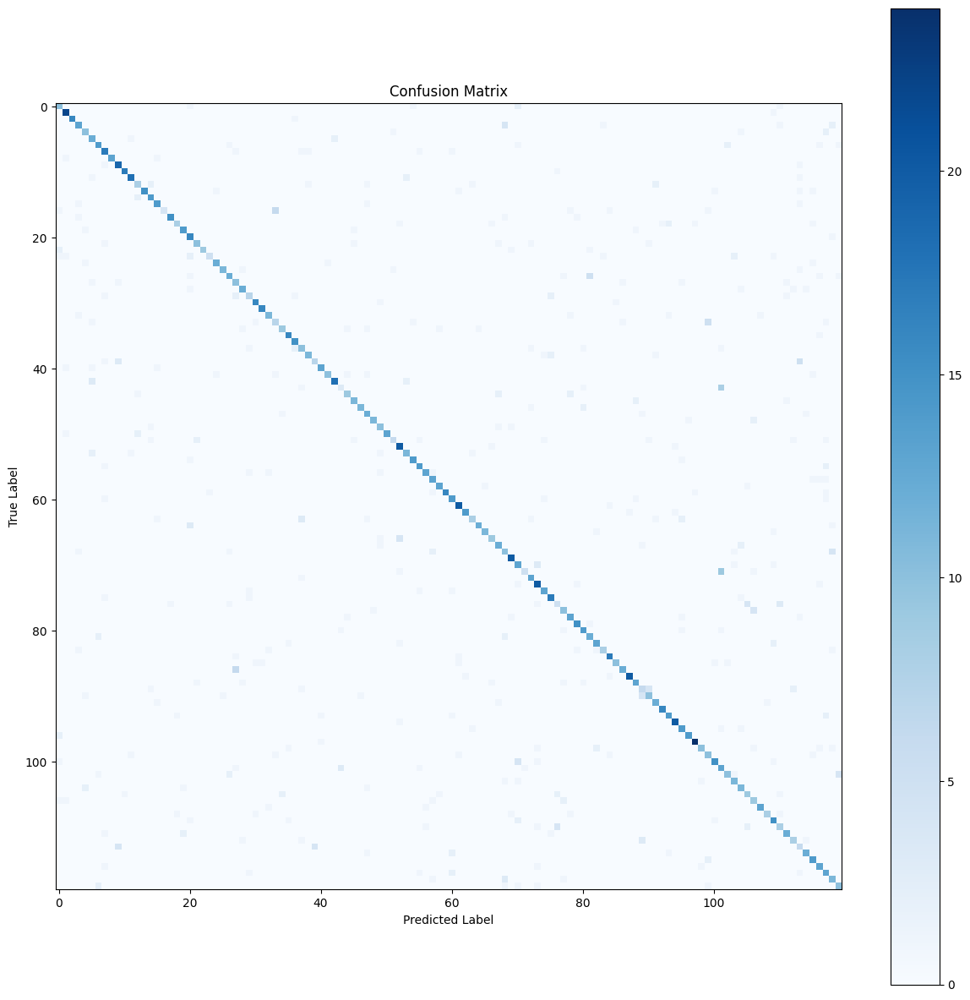

In [76]:
# Visualize confusion matrix
plt.figure(figsize=(15, 15))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()
plt.show()

# Saving and reloading a trained model

In [77]:
# Create a functon to save a model
def save_model(model, suffix=None):
  """
  Saves a given model in a models directory and appends a suffix (string).
  """
  # create a model dirctory pathname with current time
  modeldir = os.path.join("drive/MyDrive/Dog Vision/models",
                          datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
  model_path = modeldir + "-" + suffix + ".keras" # save format of model
  print(f"Saving model to: {model_path}...")
  model.save(model_path)
  return model_path

In [78]:
# create a function to load a trained model
def load_model(model_path):
  """
  Loads a saved model from a specified path.
  """
  print(f"Loading saved model from: {model_path}")
  model = tf.keras.models.load_model(model_path,
                                    custom_objects={"KerasLayer":hub.KerasLayer})
  return model

Now we've got functions to save and load a trained model, let's make sure they work!

In [79]:
save_model(model, suffix="1000-images-mobilenetv2-Adam")

Saving model to: drive/MyDrive/Dog Vision/models/20261007-125918-1000-images-mobilenetv2-Adam.keras...


'drive/MyDrive/Dog Vision/models/20261007-125918-1000-images-mobilenetv2-Adam.keras'

In [80]:
#  Load a trained model
loaded_1000_image_model = load_model('drive/MyDrive/Dog Vision/models/20261004-070814-1000-images-mobilenetv2-Adam.keras')

Loading saved model from: drive/MyDrive/Dog Vision/models/20261004-070814-1000-images-mobilenetv2-Adam.keras


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [81]:
# Evaluate the pre-saved model
model.evaluate(val_data)

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.7400 - loss: 0.8339


[0.8338522911071777, 0.7400000095367432]

In [82]:
# Evaluate the loaded model
loaded_1000_image_model.evaluate(val_data)

63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.7480 - loss: 0.8202


[0.820201575756073, 0.7480000257492065]

# Training a big dog model (on the full data)

In [83]:
len(x), len(y)

(10222, 10222)

In [84]:
# Create a data batch with the full data set
full_data = create_data_batches(x, y)

Creating training data batches...


In [85]:
full_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [86]:
# Create a full model for full model
full_model = create_model()

In [87]:
# create full model callbacks
full_model_tensorboard = create_tensorboard_callback()
# No validation set when training on all the data, so we can't monitor validation accuracy
full_model_early_stopping = tf.keras.callbacks.EarlyStopping(monitor="accuracy",
                                                             patience=3)

In [88]:
# Fit the full model to the full data
full_model.fit(x=full_data,
               epochs=NUM_EPOCHS,
               callbacks=[full_model_tensorboard, full_model_early_stopping])

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step - accuracy: 0.5965 - loss: 1.6100
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - accuracy: 0.8340 - loss: 0.5717
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 33s 102ms/step - accuracy: 0.8961 - loss: 0.3766
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.9398 - loss: 0.2578
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.9650 - loss: 0.1846
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.9819 - loss: 0.1356
Epoch 7/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 33s 103ms/step - accuracy: 0.9882 - loss: 0.1028
Epoch 8/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 33s 102ms/step - accuracy: 0.9931 - loss: 0.0804
Epoch 9/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 32s 100ms/step - accuracy: 0.9963 - loss: 0.0632
Epoch 10/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 32s 99ms/step - accuracy: 0.9976 - loss: 0.0519
Epoch 11/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 42s 102ms/step - accuracy: 0.9982 - loss: 0.0426
Epoch 12/

In [89]:
save_model(full_model, suffix="full-image-set-mobilenetv2-Adam")

Saving model to: drive/MyDrive/Dog Vision/models/20261007-131338-full-image-set-mobilenetv2-Adam.keras...


'drive/MyDrive/Dog Vision/models/20261007-131338-full-image-set-mobilenetv2-Adam.keras'

In [90]:
# Load in the full model
loaded_full_model = load_model('drive/MyDrive/Dog Vision/models/20261004-111008-full-image-set-mobilenetv2-Adam.keras')

Loading saved model from: drive/MyDrive/Dog Vision/models/20261004-111008-full-image-set-mobilenetv2-Adam.keras


## Making predictions on the test dataset

since our model has been trained on images in the form of Tensor batches, to make predictions on the test data, we'll have to get it into the same format.

Luckily we created `create_data_batches()` earlier which can take a list of filenames as input and conver them into Tensor batches.

To make predictions on the test data, we'll:
- Get the test image filenames.
- Convert the filenames into test data batches using `create_data_batches`and setting the `test_data` parameter to `True` (since the test doesn't have labels).
- Make a prediction array by passing the test batches to the `predict()` method called on our model.

In [91]:
# Load test image filenames
test_path = "drive/MyDrive/Dog Vision/test"

test_filenames = [os.path.join(test_path, fname) for fname in os.listdir(test_path)]

test_filenames[:10]

['drive/MyDrive/Dog Vision/test/e7feb64da6aae1ef8e62453f6660d0c5.jpg',
 'drive/MyDrive/Dog Vision/test/df7d17082d1b25eeba9be835a150db01.jpg',
 'drive/MyDrive/Dog Vision/test/e2d76a91641c11a0609687b83ff9c0b4.jpg',
 'drive/MyDrive/Dog Vision/test/e726ac27864ecbde1f5822c4d6e26c17.jpg',
 'drive/MyDrive/Dog Vision/test/dd1101676d8c7fa8522dd5ebd1129d17.jpg',
 'drive/MyDrive/Dog Vision/test/e073f14cd5f4c1a62cdb0108cca62fdd.jpg',
 'drive/MyDrive/Dog Vision/test/e0bf90705facb623a6f36046cc495659.jpg',
 'drive/MyDrive/Dog Vision/test/e26901a9e04f0ba89765fb9b9b7f675f.jpg',
 'drive/MyDrive/Dog Vision/test/e141811c20cade75f5cb3b7da86320a8.jpg',
 'drive/MyDrive/Dog Vision/test/e2915c191c0bc761b795b78f66845fe0.jpg']

In [92]:
len(test_filenames)

10357

In [93]:
# create test data batch
test_data = create_data_batches(test_filenames, test_data=True)

Creating test data batches...


In [94]:
test_data

<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

**Note**: Calling `predict()` on our full model and passing it the test data batch will take a long time to run

In [95]:
# Make predictions on test data batch using the loaded full model
test_predictions = loaded_full_model.predict(test_data,
                                             verbose=1)

324/324 ━━━━━━━━━━━━━━━━━━━━ 247s 739ms/step


In [96]:
# save predcitions (Numpy array) to csv file (for access later)
np.savetxt("drive/MyDrive/Dog Vision/preds_array.csv", test_predictions, delimiter=",")

In [97]:
# Load predictions (Numpy array) from csv file
test_predictions = np.loadtxt("drive/MyDrive/Dog Vision/preds_array.csv", delimiter=",")

## Preparing test dataset predictions for kaggle

Looking at the kaggle sample submission, we find that it wants our models prediction probability outputs in a DataFrame with an ID and a column for each different dog breed.

To get the data in this format, we'll
- Create a pandas DataFrame with an ID column as well as a column for each dog breed
- Add data to the ID column by extracting the test image ID's from their filepaths
- Add data (the prediction probabilities) to each of the dog breed columns
- Export the DataFrame as csv to submit it to kaggle

In [98]:
["id"] + list(unique_breeds)

['id',
 'affenpinscher',
 'afghan_hound',
 'african_hunting_dog',
 'airedale',
 'american_staffordshire_terrier',
 'appenzeller',
 'australian_terrier',
 'basenji',
 'basset',
 'beagle',
 'bedlington_terrier',
 'bernese_mountain_dog',
 'black-and-tan_coonhound',
 'blenheim_spaniel',
 'bloodhound',
 'bluetick',
 'border_collie',
 'border_terrier',
 'borzoi',
 'boston_bull',
 'bouvier_des_flandres',
 'boxer',
 'brabancon_griffon',
 'briard',
 'brittany_spaniel',
 'bull_mastiff',
 'cairn',
 'cardigan',
 'chesapeake_bay_retriever',
 'chihuahua',
 'chow',
 'clumber',
 'cocker_spaniel',
 'collie',
 'curly-coated_retriever',
 'dandie_dinmont',
 'dhole',
 'dingo',
 'doberman',
 'english_foxhound',
 'english_setter',
 'english_springer',
 'entlebucher',
 'eskimo_dog',
 'flat-coated_retriever',
 'french_bulldog',
 'german_shepherd',
 'german_short-haired_pointer',
 'giant_schnauzer',
 'golden_retriever',
 'gordon_setter',
 'great_dane',
 'great_pyrenees',
 'greater_swiss_mountain_dog',
 'groenen

In [99]:
# Create a pandas DataFrame with empty columns
preds_df = pd.DataFrame(columns=["id"] + list(unique_breeds))
preds_df

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier


In [100]:
# Append test image ID's to predictions DataFrame
test_ids = [os.path.splitext(path)[0] for path in os.listdir(test_path)]
preds_df["id"] = test_ids

In [101]:
preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,e7feb64da6aae1ef8e62453f6660d0c5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,df7d17082d1b25eeba9be835a150db01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,e2d76a91641c11a0609687b83ff9c0b4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e726ac27864ecbde1f5822c4d6e26c17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,dd1101676d8c7fa8522dd5ebd1129d17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
# Add the prediction probablities to each dog breed column
preds_df[list(unique_breeds)] =test_predictions
preds_df.head()

,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,e7feb64da6aae1ef8e62453f6660d0c5,3.012651e-08,5.210636e-06,9.356919e-11,5.641346e-12,2.989955e-11,3.128518e-12,7.768771e-10,1.210131e-11,7.991564e-10,...,4.118244e-09,1.611107e-10,3.008233e-10,1.922874e-12,1.175398e-12,4.462055e-10,1.288004e-10,6.801862e-10,1.212428e-11,9.630309e-07
1,df7d17082d1b25eeba9be835a150db01,5.134674e-09,4.482215e-10,4.328036e-04,4.338565e-10,8.198271e-09,2.038070e-09,1.675884e-07,2.800551e-07,1.355580e-09,...,6.720081e-11,5.524526e-09,1.290173e-08,5.246921e-10,2.923366e-10,6.141390e-10,2.056927e-10,9.306374e-08,1.021009e-10,7.373815e-10
2,e2d76a91641c11a0609687b83ff9c0b4,2.842773e-05,5.032091e-10,1.218720e-12,9.736523e-12,2.163885e-12,3.422870e-16,1.523714e-14,3.626884e-11,1.538280e-13,...,8.935456e-11,1.842554e-14,6.115917e-13,4.602230e-18,3.671091e-12,8.962514e-14,1.239962e-13,5.730646e-08,9.482064e-13,1.056793e-11
3,e726ac27864ecbde1f5822c4d6e26c17,7.802831e-08,3.588063e-07,1.133039e-06,2.280925e-07,2.026132e-03,1.910235e-07,1.348831e-10,4.016878e-06,2.401250e-08,...,1.577989e-08,3.990575e-08,5.333693e-06,4.798575e-07,5.143675e-04,9.946825e-09,2.916885e-07,9.642386e-02,3.749091e-08,1.648837e-07
4,dd1101676d8c7fa8522dd5ebd1129d17,2.023167e-04,7.582339e-13,6.111958e-10,1.201590e-08,2.496093e-12,3.476239e-09,3.480237e-14,2.429306e-09,3.368075e-11,...,1.450860e-09,2.292565e-10,4.936695e-11,5.603415e-15,5.081353e-10,2.114468e-11,5.307991e-11,1.884772e-08,1.248082e-11,1.321386e-09


In [103]:
# Save the model predictions dataframe to csv
preds_df.to_csv("drive/MyDrive/Dog Vision/full_model_predictions_submission_1_mobilenetV2.csv",
                index=False)

## Making predictions on custom images

It's great being able to make predictions on a test dataset already provided for us.

But how could we use our model on our own images?

The premise remains, if we want to make predictions on our own custom images, we have to pass them to the model in the same format the model was trained on.

To do so, we'll:

- Get the filepaths of our own images.
- Turn the filepaths into data batches using `create_data_batches()`. And since our custom images won't have labels, we set the `test_data` parameter to `True`.
- Pass the custom image data batch to our model's `predict()` method.
- Convert the prediction output probabilities to prediction labels.
- Compare the predicted labels to the custom images.

**Note**: To make predictions on custom images, I've uploaded pictures of my own to a directory located at `drive/MyDrive/Data/` dogs/ (as seen in the cell below). In order to make predictions on your own images, you will have to do something similar.

In [108]:
# Get custom image filepaths
custom_path = "/content/drive/MyDrive/Dog Vision/dogs"
custom_image_paths = [os.path.join(custom_path, fname) for fname in os.listdir(custom_path)]

In [109]:
custom_path

'/content/drive/MyDrive/Dog Vision/dogs'

In [110]:
# Turn custom images into batch datasets
custom_data = create_data_batches(custom_image_paths, test_data=True)
custom_data

Creating test data batches...


<_BatchDataset element_spec=TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)>

In [111]:
# Make predictions on the custom data
custom_preds = loaded_full_model.predict(custom_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [112]:
custom_preds.shape

(7, 120)

In [113]:
# Get custom image prediction labels
custom_pred_labels = [get_pred_label(custom_preds[i]) for i in range(len(custom_preds))]
custom_pred_labels

['norwich_terrier',
 'german_shepherd',
 'toy_poodle',
 'toy_poodle',
 'kerry_blue_terrier',
 'standard_poodle',
 'malinois']

In [114]:
# Get custom images (our unbatchify() function won't work since there aren't labels)
custom_images = []
# loop through unbatched data
for image in custom_data.unbatch().as_numpy_iterator():
  custom_images.append(image)

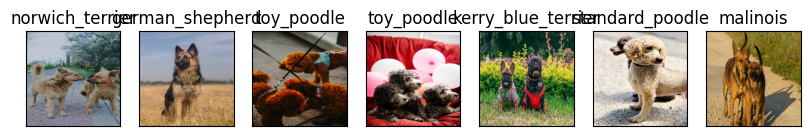

In [116]:
# check custom image predictions

plt.figure(figsize=(10, 10))

num_images = len(custom_images)

for i, image in enumerate(custom_images):
    plt.subplot(1, num_images, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.title(custom_pred_labels[i])
    plt.imshow(image)

plt.show()

## What's next?

This is the same style of problem self-driving cars have, except with different data.

If you're looking on where to go next, you've got plenty of options.

You could try to improve the full model we trained in this notebook in a few ways (there are a fair few options). Since our early experiment (using only 1000 images) hinted at our model overfitting (the results on the training set far outperformed the results on the validation set), one goal going forward would be to try and prevent it.

1. Trying another model from TensorFlow Hub - Perhaps a different model would perform better on our dataset. One option would be to experiment with a different pretrained model from TensorFlow Hub or look into the `tf.keras.applications module`.

2. Data augmentation - Take the training images and manipulate (crop, resize) or distort them (flip, rotate) to create even more training data for the model to learn from. Check out the TensorFlow images documentation for a whole bunch of functions you can use on images. A great idea would be to try and replicate the techniques in this example cat vs. dog image classification notebook for our dog breeds problem.

3. Fine-tuning - The model we used in this notebook was directly from TensorFlow Hub, we took what it had already learned from another dataset (ImageNet) and applied it to our own. Another option is to use what the model already knows and fine-tune this knowledge to our own dataset (pictures of dogs). This would mean all of the patterns within the model would be updated to be more specific to pictures of dogs rather than general images.

If you're ever after more, one of the best ways to find out something is to search for something like:

- "How to improve a TensorFlow 2.x image classification model?"
- "TensorFlow 2.x image classification best practices"
- "Transfer learning for image classification with TensorFlow 2.x"

And when you see an example you think might be beyond your reach (because it looks too complicated), remember, if in doubt, run the code. Try and reproduce what you see. This is the best way to get hands-on and build your own knowledge.

No one starts out knowing how to do everything single thing. They just get better are knowing what to look for.